Estimate across-event TE between pairs of regions around hippocampal and cortical events

In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import fmatoolbox as fma
import frites
import xarray as xr
import ISRUtilities as isru
import pathlib
froot = pathlib.Path().cwd().parent.parent.parent / 'Results/Figures/ISAHpcPfc'
batch_file = '/mnt/hubel-data-103/Pietro/InfraSlowNRPaper/Data/IS_intervals.batch'
do_save = False

ModuleNotFoundError: No module named 'frites'

In [34]:
def _regionPETE(session,regs=None,n_shuffle=0):
    # estimate transfer entropy (TE) across regions around ripple peak times as (shuffle, region, lag) XArray
    # 'shuffle' coordinate is False iff corresponding data values are real

    R = rg.data.Regions(session,states='sws',events=['InfraSlowRhythm/slownr','InfraSlowRhythm/slowavalnr','ripples'])
    regs = R.ids if regs is None else np.array(regs)
    is_reg = np.isin(regs,R.ids) # is_reg[i] is True if regs[i] is in R.ids SHOULD USE THIS
    rip_time = R.eventInfo('ripples')[:,2]
    firing_rate = R.firingRate()

    # IEI SHUFFLE
    shuffled_rip_time = np.zeros((len(rip_time),n_shuffle+1)) # each column is a shuffle, first is observed
    shuffled_rip_time[:,0] = rip_time
    for i in range(n_shuffle):
        shuffled_rip_time[:,i+1] = fma.general.shuffleEvents(rip_time,intervals=R.eventIntervals('sws'))

    TE = []
    for i in range(n_shuffle+1):
        rip_peth, t, _ = fma.analysis.PETH(firing_rate,shuffled_rip_time[:,i],limits=[-0.5,0.5],n_bins=101)
        TE.append(frites.conn.conn_te(np.transpose(rip_peth,(0,2,1)),t,R.ids,verbose=False))
    shuffle = xr.DataArray([False]+[True]*n_shuffle,dims='shuffle')
    xdata = xr.concat(TE,dim=shuffle)

    return xdata

In [17]:
# coupl: False dominates effect, True very noisy
def _regionPETECoupl(session,regs=None,n_shuffle=0,rnd_seed=None):
    # estimate transfer entropy (TE) across regions around event peak times as (shuffle, region, lag) XArray
    # surrogate data is produced by circular shift of events, 'shuffle' coordinate is False iff corresponding data values are real

    # load data
    R = fma.regions.regions(session,events='InfraSlowRhythm/infraslowaval')
    regs = R.ids if regs is None else np.array(regs)[np.isin(regs,R.ids)]
    firing_rate = R.firingRate(regs=regs,norm=True)
    events, is_coupl = isru.loadHpcPfcEvents(session,coupl=True)

    peth = {}
    TE = []
    rng = np.random.default_rng(rnd_seed)
    shift = rng.integers(-5,5,size=(n_shuffle,len(regs))) # shift[i,j] is used to roll region j at shuffle i
    names = []
    for name in events:
        if len(events[name]):
            names.append(name)
            TE.append([])
            for coupl in [False,True]: # False: coupled, True: uncoupled

                # peth for coupled or uncoupled events
                this_events = events[name][coupl ^ is_coupl[name]]
                p, t, _ = fma.analysis.PETH(firing_rate,this_events,limits=[-0.5,0.5],n_bins=101)
                peth[name] = np.transpose(p,(0,2,1)) # (ripples, region, times)

                # observed TE
                te = frites.conn.conn_te(peth[name],t,regs,verbose=False)
                TE[-1].append([te])

                # circular shuffle
                n_events, n_regs, n_times = peth[name].shape
                for i in range(n_shuffle):
                    idx = (np.arange(n_events)[:,None] - shift[i,:]) % n_events # idx[:,j] shifts the ripple axis for region j
                    shifted_peth = peth[name][idx,np.arange(n_regs),:] # np.arange(n_regs) NECESSARY??
                    te = frites.conn.conn_te(shifted_peth,t,regs,verbose=False)
                    TE[-1][-1].append(te)

    xdata = xr.DataArray(TE,dims=['event','coupl','shuf','reg','t'],coords={'event': names, 'coupl': [True,False] , 'shuf': [False]+[True]*n_shuffle, 'reg': te['roi'].values, 't': te['times'].values, 'rat': int(R.rat)})

    return xdata, shift

In [2]:
# isa:
def _regionPETEISA(session,regs=None,n_shuffle=0,rnd_seed=None):
    # estimate transfer entropy (TE) across regions around event peak times as (shuffle, region, lag) XArray
    # surrogate data is produced by circular shift of events, 'shuffle' coordinate is False iff corresponding data values are real

    # load data
    R = fma.regions.regions(session,events='InfraSlowRhythm/infraslowaval')
    regs = R.ids if regs is None else np.array(regs)[np.isin(regs,R.ids)]
    firing_rate = R.firingRate(regs=regs,norm=True)
    events = isru.loadHpcPfcEvents(session)

    peth = {}
    TE = []
    rng = np.random.default_rng(rnd_seed)
    shift = rng.integers(-5,5,size=(n_shuffle,len(regs))) # shift[i,j] is used to roll region j at shuffle i
    names = []
    for name in events:
        if len(events[name]):
            names.append(name)
            TE.append([])
            _, is_isa = fma.general.restrict(events[name],R.eventIntervals('slownr'),s_ind=True)
            for isa in [False,True]: # False: ISA, True: nISA

                # peth for coupled or uncoupled events
                this_events = events[name][isa ^ is_isa]
                p, t, _ = fma.analysis.PETH(firing_rate,this_events,limits=[-0.5,0.5],n_bins=101)
                peth[name] = np.transpose(p,(0,2,1)) # (ripples, region, times)

                # observed TE
                te = frites.conn.conn_te(peth[name],t,regs,verbose=False)
                TE[-1].append([te])

                # circular shuffle
                n_events, n_regs, n_times = peth[name].shape
                for i in range(n_shuffle):
                    idx = (np.arange(n_events)[:,None] - shift[i,:]) % n_events # idx[:,j] shifts the ripple axis for region j
                    shifted_peth = peth[name][idx,np.arange(n_regs),:] # np.arange(n_regs) NECESSARY??
                    te = frites.conn.conn_te(shifted_peth,t,regs,verbose=False)
                    TE[-1][-1].append(te)

    xdata = xr.DataArray(TE,dims=['event','isa','shuf','reg','t'],coords={'event': names, 'isa': [True,False] , 'shuf': [False]+[True]*n_shuffle, 'reg': te['roi'].values, 't': te['times'].values, 'rat': int(R.rat)})

    return xdata, shift

In [7]:
def _regionPETEShift(session,regs=None,lim=[-0.5,0.3],bin=0.01,n_shuffle=0,rnd_seed=None):
    # estimate transfer entropy (TE) across regions around event peak times as (shuffle, region, lag) XArray
    # surrogate data is produced by circular shift of events, 'shuffle' coordinate is False iff corresponding data values are real

    # load data
    R = fma.regions.regions(session,events='InfraSlowRhythm/infraslowaval')
    regs = R.ids if regs is None else np.array(regs)[np.isin(regs,R.ids)]
    firing_rate = R.firingRate(regs=regs,norm=True)
    events = isru.loadHpcPfcEvents(session)

    # TE parameters
    max_delay = 10
    rng = np.random.default_rng(rnd_seed)
    shift = rng.integers(-5,5,size=(n_shuffle,len(regs))) # shift[i,j] is used to roll region j at shuffle i

    peth = {}
    TE = []
    names = []
    for name in events:
        if len(events[name]):
            names.append(name)

            p, t, _ = fma.analysis.PETH(firing_rate,events[name],limits=lim,bin=bin)
            peth[name] = np.transpose(p,(0,2,1)) # (ripples, region, times)
            te = frites.conn.conn_te(peth[name],times=t,roi=regs,max_delay=max_delay,verbose=False)
            TE.append([te])

            # circular shuffle
            n_events, n_regs, n_times = peth[name].shape
            for i in range(n_shuffle):
                idx = (np.arange(n_events)[:,None] - shift[i,:]) % n_events # idx[:,j] shifts the ripple axis for region j
                shifted_peth = peth[name][idx,np.arange(n_regs),:]
                te = frites.conn.conn_te(shifted_peth,times=t,roi=regs,max_delay=max_delay,verbose=False)
                TE[-1].append(te)

    xdata = xr.DataArray(TE,dims=['event','shuf','reg','t'],coords={'event': names, 'shuf': [False]+[True]*n_shuffle, 'reg': te['roi'].values, 't': te['times'].values, 'rat': int(R.rat)})

    return xdata, shift

In [9]:
regs = ['hpc','nr','pfc']
session = fma.data.readBatchFile(batch_file)[0][13]
print(f'session: {session}')
xsession, _ = _regionPETEShift(session,regs=regs,n_shuffle=10)

session: /mnt/hubel-data-139/perceval/Rat003_20231229/Rat003_20231229.xml


KeyboardInterrupt: 

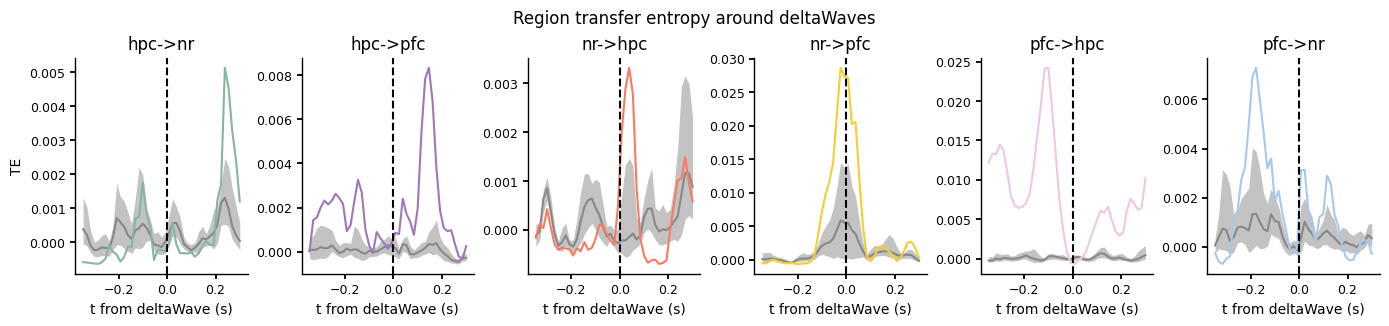

In [7]:
name = 'deltaWaves'
fig, axs = fma.plotting.makeFigure(f'Region transfer entropy around {name}',[1,6],[35,8])
for i, r in enumerate(xsession['reg'].values):
    reg_data = xsession.sel(event=name,reg=r)
    fma.plotting.semPlot(xsession['t'],reg_data.sel(shuf=True),zscore=False,color=isru.paperColors('shuffle'),label=r.upper(),ax=axs[i])
    axs[i].plot(xsession['t'],reg_data.sel(shuf=False),color=isru.paperColors(i),label=str(r.item().upper()))
    axs[i].set_xlabel(f't from {name[:-1]} (s)'), axs[i].set_title(r)
    axs[i].axvline(0,ls='--',color='k')
axs[0].set_ylabel('TE');

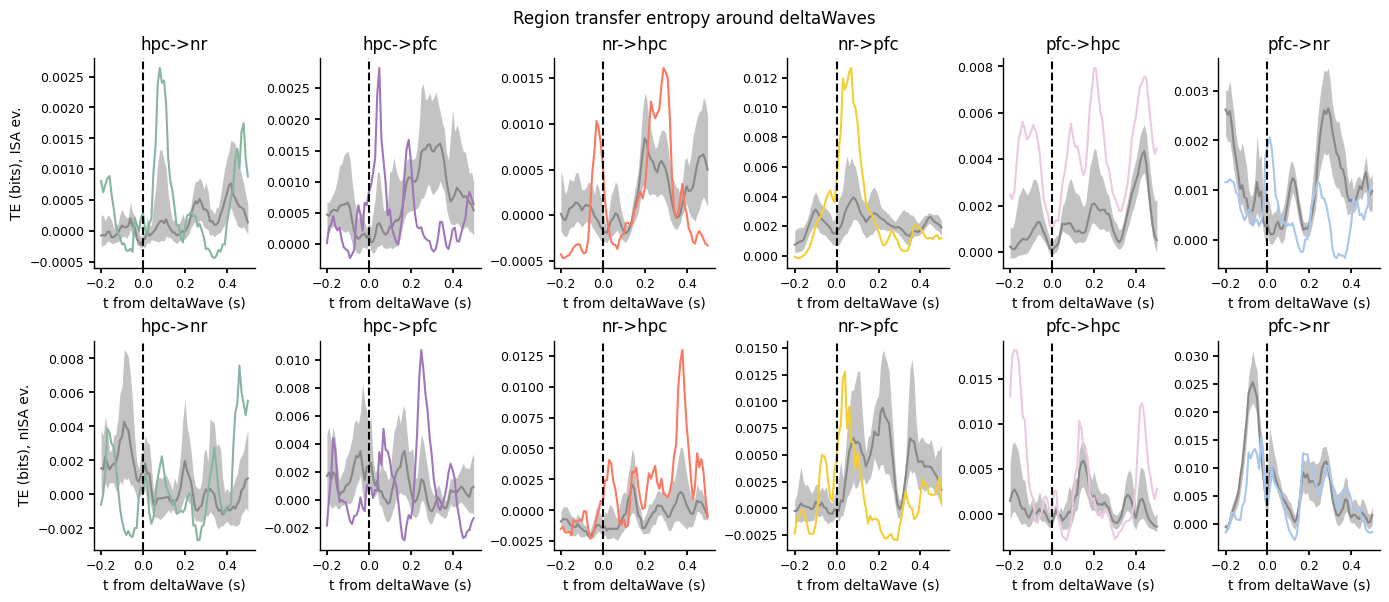

In [6]:
# see results divided by coupling
name = 'deltaWaves'
fig, axs = fma.plotting.makeFigure(f'Region transfer entropy around {name}',[2,6],[35,15])
for i, r in enumerate(xsession['reg'].values):
    for j, condition in enumerate([True,False]):
        reg_data = xsession.sel(event=name,isa=condition,reg=r)
        fma.plotting.semPlot(xsession['t'],reg_data.sel(shuf=True),zscore=False,color=isru.paperColors('shuffle'),label=r.upper(),ax=axs[j,i])
        axs[j,i].plot(xsession['t'],reg_data.sel(shuf=False),color=isru.paperColors(i),label=str(r.item().upper()))
        axs[j,i].set_xlabel(f't from {name[:-1]} (s)'), axs[j,i].set_title(r)
        axs[j,i].axvline(0,ls='--',color='k')
axs[0,0].set_ylabel('TE (bits), ISA ev.'); axs[1,0].set_ylabel('TE (bits), nISA ev.');

run batch

In [3]:
regs = ['hpc','nr','pfc']
xdata, shifts = fma.data.runBatch(batch_file,_regionPETEShift,kwargs={'regs': regs,'n_shuffle': 50},rnd_seed='rnd_seed',parallel=True)
# concatenate data
data_cat = xr.concat([d for d in xdata if d is not None],dim='rat',join='outer')
data_avg = data_cat.groupby('rat').mean(dim='rat',skipna=True)


Starting Batch, 2026-07-03 16:25:32.479306 



/home/pietro/uvEnvs/frites/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/pietro/uvEnvs/frites/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/pietro/uvEnvs/frites/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/pietro/uvEnvs/frites/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from

Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230807/Rat002_20230807.xml (31)
local variable 'te' referenced before assignment
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230808/Rat002_20230808.xml (32)
local variable 'te' referenced before assignment
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230810/Rat002_20230810.xml (33)
local variable 'te' referenced before assignment
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230815/Rat002_20230815.xml (34)
local variable 'te' referenced before assignment
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230816/Rat002_20230816.xml (35)
local variable 'te' referenced before assignment
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230817/Rat002_20230817.xml (36)
local variable 'te' referenced before assignment
Traceback:
Error in session /mnt/hubel-data-148/blinky/Training/Rat002_20230818/Rat002_

In [11]:
# grand-average statistical test
#pval = {r.item(): fma.analysis.maxStatisticTest(data_cat.sel(roi=r,shuffle=False),
#        data_cat.sel(roi=r,shuffle=True).transpose('session','times',...)) for r in data_cat.roi}

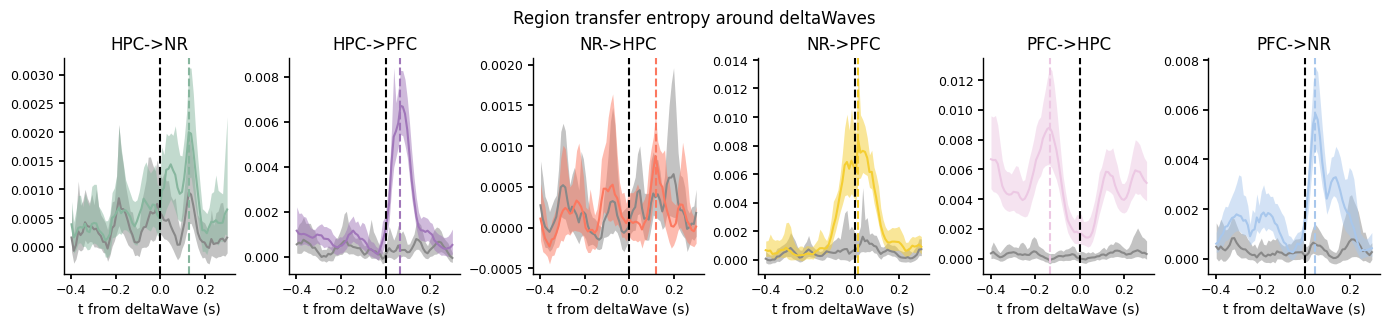

In [4]:
# DO: ISR vs nISR and CHECK JUST sleep2 FIRST 20 min!!! I COULD MAYBE EXPLORE min_delay max_delay
# meaning A->B : for a certain t, amount of help given by A to predict what B does (across ripples)
name = 'deltaWaves'
fig, axs = fma.plotting.makeFigure(f'Region transfer entropy around {name}',[1,6],[35,8])
for i, r in enumerate(data_cat['reg'].values):
    reg_data = data_cat.sel(event=name,reg=r)
    fma.plotting.semPlot(data_cat['t'],reg_data.isel(shuf=10),zscore=False,color=isru.paperColors('shuffle'),label=r.upper(),ax=axs[i])
    #fma.plotting.semPlot(data_cat['t'],reg_data.stack(d=('session','shuffle')).transpose('d','times'),zscore=False,color='#AAAAAA',label=r.upper(),ax=axs[i])
    fma.plotting.semPlot(data_cat['t'],reg_data.sel(shuf=False),zscore=False,color=isru.paperColors(i),label=r.upper(),ax=axs[i])
    peak_time = np.argmax(reg_data.sel(shuf=False).mean('rat').data)
    axs[i].axvline(reg_data.t[peak_time],ls='--',color=isru.paperColors(i)),
    axs[i].axvline(0,ls='--',color='k'), axs[i].set_xlabel(f't from {name[:-1]} (s)'), axs[i].set_title(r.upper())
    # statistical significance
    #fma.plotting.pHorzLine(pval[r],data_cat['t'],color=isru.paperColors(i),ax=axs[i])
#fma.plotting.saveFigure(fig,froot/'ISRipplesSpindles/3l_fr_rip_TE',['svg','png'])

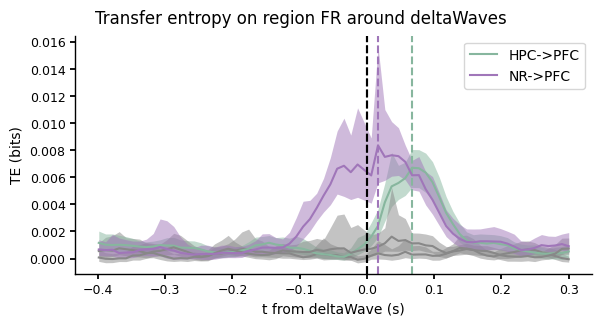

In [5]:
# NR predicts PFC after delta waves before and better than HPC, pooled
name = 'deltaWaves'
fig, axs = fma.plotting.makeFigure(f'Transfer entropy on region FR around {name}',size=[15,8])
for i, r in enumerate(data_cat['reg'].values):
    if r[-3:] == 'pfc':
        reg_data = data_cat.sel(event=name,reg=r)
        fma.plotting.semPlot(data_cat['t'],reg_data.isel(shuf=10),zscore=False,color=isru.paperColors('shuffle'),label='',ax=axs[0])
        #fma.plotting.semPlot(data_cat['t'],reg_data.stack(d=('session','shuffle')).transpose('d','times'),zscore=False,color='#AAAAAA',label=r.upper(),ax=axs[i])
        fma.plotting.semPlot(data_cat['t'],reg_data.sel(shuf=False),zscore=False,color=isru.paperColors(r.split('-')[0]),label=r.upper(),ax=axs[0])
        peak_time = np.argmax(reg_data.sel(shuf=False).mean('rat').data)
        axs[0].axvline(reg_data.t[peak_time],ls='--',color=isru.paperColors(r.split('-')[0])),
        axs[0].axvline(0,ls='--',color='k'), axs[0].set_xlabel(f't from {name[:-1]} (s)')
        # statistical significance
        #fma.plotting.pHorzLine(pval[r],data_cat['t'],color=isru.paperColors(i),ax=axs[i])
axs[0].legend(); axs[0].set(ylabel='TE (bits)');
#fma.plotting.saveFigure(fig,froot/'ISRipplesSpindles/3l_fr_rip_TE',['svg','png'])

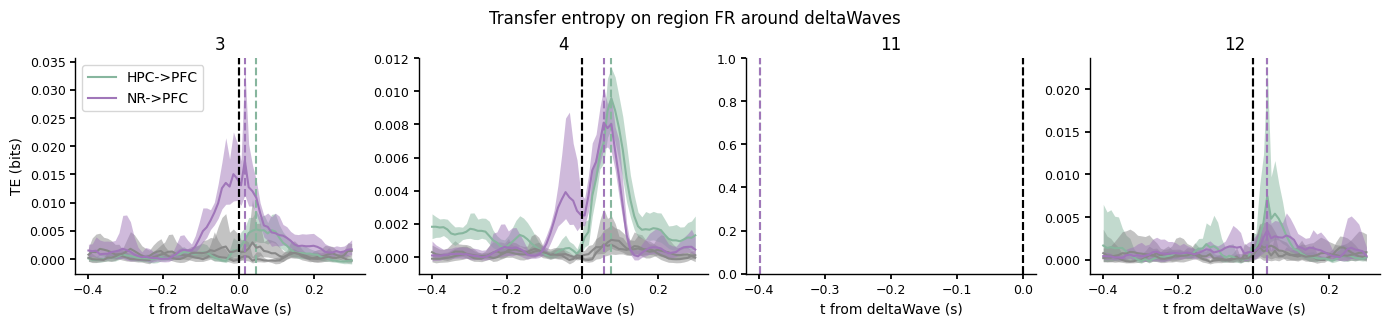

In [6]:
# see per animal
name = 'deltaWaves'
fig, axs = fma.plotting.makeFigure(f'Transfer entropy on region FR around {name}',n=[1,4],size=[35,8])
for j, rat in enumerate(data_avg['rat'].values):
    for i, r in enumerate(data_cat['reg'].values):
        if r[-3:] == 'pfc':
            reg_data = data_cat.sel(event=name,reg=r,rat=rat)
            fma.plotting.semPlot(data_cat['t'],reg_data.isel(shuf=10),zscore=False,color=isru.paperColors('shuffle'),label='',ax=axs[j])
            #fma.plotting.semPlot(data_cat['t'],reg_data.stack(d=('session','shuffle')).transpose('d','times'),zscore=False,color='#AAAAAA',label=r.upper(),ax=axs[i])
            fma.plotting.semPlot(data_cat['t'],reg_data.sel(shuf=False),zscore=False,color=isru.paperColors(r.split('-')[0]),label=r.upper(),ax=axs[j])
            peak_time = np.argmax(reg_data.sel(shuf=False).mean('rat').data)
            axs[j].axvline(reg_data.t[peak_time],ls='--',color=isru.paperColors(r.split('-')[0])),
            axs[j].axvline(0,ls='--',color='k'), axs[j].set_xlabel(f't from {name[:-1]} (s)'), axs[j].set_title(rat)
            # statistical significance
            #fma.plotting.pHorzLine(pval[r],data_cat['t'],color=isru.paperColors(i),ax=axs[i])
axs[0].legend(); axs[0].set(ylabel='TE (bits)');
#fma.plotting.saveFigure(fig,froot/'ISRipplesSpindles/3l_fr_rip_TE',['svg','png'])

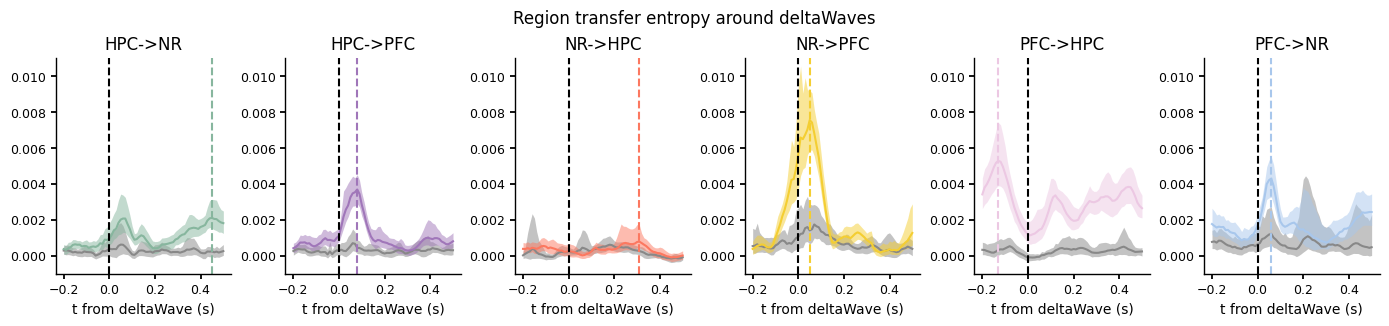

In [8]:
# meaning A->B : for a certain t, amount of help given by A to predict what B does (across ripples)
name = 'deltaWaves'
fig, axs = fma.plotting.makeFigure(f'Region transfer entropy around {name}',[1,6],[35,8])
for i, r in enumerate(data_cat['reg'].values):
    reg_data = data_cat.sel(event=name,reg=r)
    fma.plotting.semPlot(data_cat['t'],reg_data.isel(shuf=10),zscore=False,color=isru.paperColors('shuffle'),label=r.upper(),ax=axs[i])
    #fma.plotting.semPlot(data_cat['t'],reg_data.stack(d=('session','shuffle')).transpose('d','times'),zscore=False,color='#AAAAAA',label=r.upper(),ax=axs[i])
    fma.plotting.semPlot(data_cat['t'],reg_data.sel(shuf=False),zscore=False,color=isru.paperColors(i),label=r.upper(),ax=axs[i])
    peak_time = np.argmax(reg_data.sel(shuf=False).mean('rat').data)
    axs[i].axvline(reg_data.t[peak_time],ls='--',color=isru.paperColors(i)),
    axs[i].axvline(0,ls='--',color='k'), axs[i].set_xlabel(f't from {name[:-1]} (s)'), axs[i].set_title(r.upper())
    # statistical significance
    #fma.plotting.pHorzLine(pval[r],data_cat['t'],color=isru.paperColors(i),ax=axs[i])
fma.plotting.setProp(axs,ylim=[-0.001,0.011])
#fma.plotting.saveFigure(fig,froot/'ISRipplesSpindles/3l_fr_rip_TE',['svg','png'])

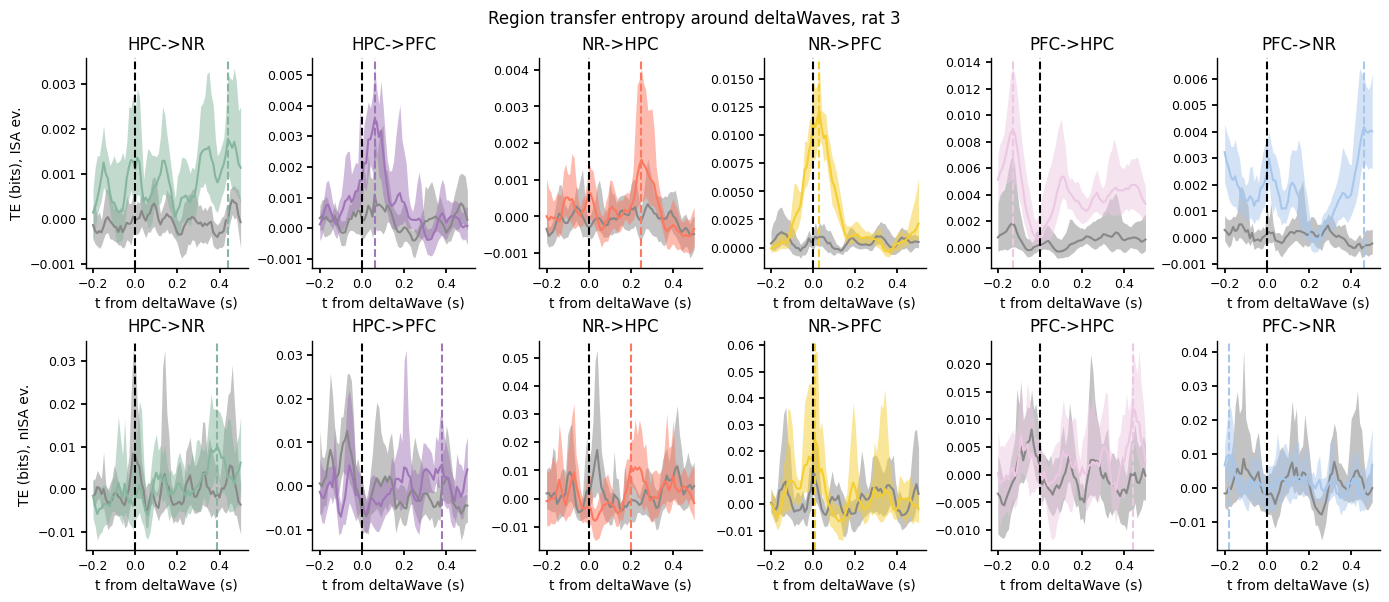

In [10]:
# see results per coupled / uncoupled, per rat
name = 'deltaWaves'
rat = 3
fig, axs = fma.plotting.makeFigure(f'Region transfer entropy around {name}, rat {rat}',[2,6],[35,15])
for i, r in enumerate(data_cat['reg'].values):
    for j, condition in enumerate([True,False]):
        reg_data = data_cat.sel(rat=rat,event=name,isa=condition,reg=r)
        fma.plotting.semPlot(data_cat['t'],reg_data.isel(shuf=10),zscore=False,color=isru.paperColors('shuffle'),label=r.upper(),ax=axs[j,i])
        #fma.plotting.semPlot(data_cat['t'],reg_data.stack(d=('session','shuffle')).transpose('d','times'),zscore=False,color='#AAAAAA',label=r.upper(),ax=axs[i])
        fma.plotting.semPlot(data_cat['t'],reg_data.sel(shuf=False),zscore=False,color=isru.paperColors(i),label=r.upper(),ax=axs[j,i])
        peak_time = np.argmax(reg_data.sel(shuf=False).mean('rat').data)
        axs[j,i].axvline(reg_data.t[peak_time],ls='--',color=isru.paperColors(i)),
        axs[j,i].axvline(0,ls='--',color='k'), axs[j,i].set_xlabel(f't from {name[:-1]} (s)'), axs[j,i].set_title(r.upper())
        # statistical significance
        #fma.plotting.pHorzLine(pval[r],data_cat['t'],color=isru.paperColors(i),ax=axs[i])
axs[0,0].set_ylabel('TE (bits), ISA ev.'); axs[1,0].set_ylabel('TE (bits), nISA ev.');
#fma.plotting.setProp(axs,ylim=[-0.001,0.011])
#fma.plotting.saveFigure(fig,froot/'ISRipplesSpindles/3l_fr_rip_TE',['svg','png'])

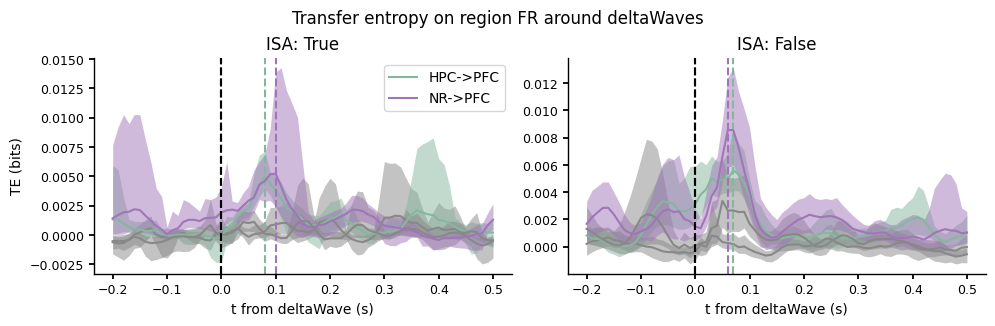

In [18]:
# NR predicts PFC after delta waves before and better than HPC, ISA vs nISA
name = 'deltaWaves'
fig, axs = fma.plotting.makeFigure(f'Transfer entropy on region FR around {name}',n=(1,2),size=(25,8))
for i, r in enumerate(data_cat['reg'].values):
    if r[-3:] == 'pfc':
        for j, condition in enumerate([True,False]):
            reg_data = data_cat.sel(event=name,reg=r,isa=condition,rat=4)
            fma.plotting.semPlot(data_cat['t'],reg_data.isel(shuf=10),zscore=False,color=isru.paperColors('shuffle'),label='',ax=axs[j])
            #fma.plotting.semPlot(data_cat['t'],reg_data.stack(d=('session','shuffle')).transpose('d','times'),zscore=False,color='#AAAAAA',label=r.upper(),ax=axs[i])
            fma.plotting.semPlot(data_cat['t'],reg_data.sel(shuf=False),zscore=False,color=isru.paperColors(r.split('-')[0]),label=r.upper(),ax=axs[j])
            peak_time = np.argmax(reg_data.sel(shuf=False).mean('rat').data)
            axs[j].axvline(reg_data.t[peak_time],ls='--',color=isru.paperColors(r.split('-')[0])),
            axs[j].axvline(0,ls='--',color='k'), axs[j].set_xlabel(f't from {name[:-1]} (s)'), axs[j].set_title(f'ISA: {condition}')
            # statistical significance
            #fma.plotting.pHorzLine(pval[r],data_cat['t'],color=isru.paperColors(i),ax=axs[i])
axs[0].legend(); axs[0].set(ylabel='TE (bits)');
#fma.plotting.saveFigure(fig,froot/'ISRipplesSpindles/3l_fr_rip_TE',['svg','png'])

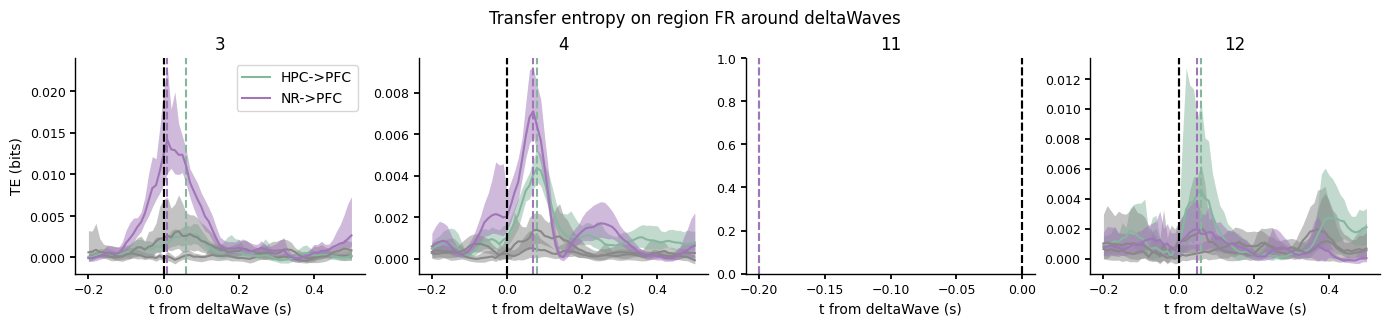

In [18]:
# NR predicts PFC after delta waves before than HPC MAYBE True?? boxplot differences of peaks
name = 'deltaWaves'
fig, axs = fma.plotting.makeFigure(f'Transfer entropy on region FR around {name}',n=[1,4],size=[35,8])
for j, rat in enumerate(data_avg['rat'].values):
    for i, r in enumerate(data_cat['reg'].values):
        if r[-3:] == 'pfc':
            reg_data = data_cat.sel(event=name,reg=r,rat=rat)
            fma.plotting.semPlot(data_cat['t'],reg_data.isel(shuf=10),zscore=False,color=isru.paperColors('shuffle'),label='',ax=axs[j])
            #fma.plotting.semPlot(data_cat['t'],reg_data.stack(d=('session','shuffle')).transpose('d','times'),zscore=False,color='#AAAAAA',label=r.upper(),ax=axs[i])
            fma.plotting.semPlot(data_cat['t'],reg_data.sel(shuf=False),zscore=False,color=isru.paperColors(r.split('-')[0]),label=r.upper(),ax=axs[j])
            peak_time = np.argmax(reg_data.sel(shuf=False).mean('rat').data)
            axs[j].axvline(reg_data.t[peak_time],ls='--',color=isru.paperColors(r.split('-')[0])),
            axs[j].axvline(0,ls='--',color='k'), axs[j].set_xlabel(f't from {name[:-1]} (s)'), axs[j].set_title(rat)
            # statistical significance
            #fma.plotting.pHorzLine(pval[r],data_cat['t'],color=isru.paperColors(i),ax=axs[i])
axs[0].legend(); axs[0].set(ylabel='TE (bits)');
#fma.plotting.saveFigure(fig,froot/'ISRipplesSpindles/3l_fr_rip_TE',['svg','png'])

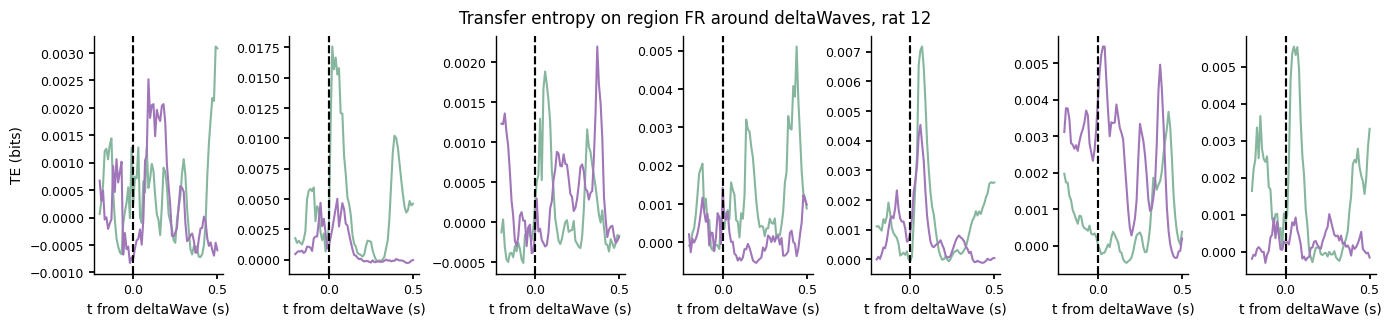

In [29]:
# NR predicts PFC after delta waves before and better than HPC, one rat
name = 'deltaWaves'
rat = 12
fig, axs = fma.plotting.makeFigure(f'Transfer entropy on region FR around {name}, rat {rat}',n=(1,7),size=(35,8))
for i, r in enumerate(data_cat['reg'].values):
    if r[-3:] == 'pfc':
        reg_data = data_cat.sel(event=name,reg=r,rat=rat)
        for j in range(7):
            #fma.plotting.semPlot(data_cat['t'],reg_data.isel(shuf=10),zscore=False,color=isru.paperColors('shuffle'),label='',ax=axs[j])
            axs[j].plot(data_cat['t'],reg_data.sel(shuf=False)[j],color=isru.paperColors(r.split('-')[0]))
            axs[j].axvline(0,ls='--',color='k'), axs[j].set_xlabel(f't from {name[:-1]} (s)')
        # statistical significance
        #fma.plotting.pHorzLine(pval[r],data_cat['t'],color=isru.paperColors(i),ax=axs[i])
axs[0].set(ylabel='TE (bits)');
#fma.plotting.saveFigure(fig,froot/'ISRipplesSpindles/3l_fr_rip_TE',['svg','png'])

Divide ISa n ISA, coupl and not, sleep1 sleep 2